# Assignment and Exam Outcomes by Course

This notebook restores the assignment comparison before the exam-score heterogeneity analysis. Assignment and exam outcomes use the original score scale, matching the other result figures, and all statistical comparisons remain separate by course.


## Setup

The roster supplies randomized assignment to Control and Experimental conditions. Homework files supply Assignment 1 (`HW1`) and Exam (`HW2`) scores. `SHOW_FIGURES` follows the existing notebooks: it can be set to `False` for headless runs.

In [1]:
from pathlib import Path
import contextlib
import io
import json
import math
import os
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', message='This figure includes Axes that are not compatible with tight_layout')
plt.close('all')


def _find_repo_root():
    '''Find the repository root from either Jupyter or the test runner.'''
    start = Path.cwd().resolve()
    for candidate in (start, *start.parents):
        if (candidate / 'pyproject.toml').exists() and (candidate / 'analyze').exists():
            return candidate
    raise RuntimeError('Could not locate repository root.')


REPO_ROOT = _find_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

FIGURES_DIR = REPO_ROOT / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
SHOW_FIGURES = os.environ.get('SHOW_FIGURES', '1').strip().lower() not in {'0', 'false', 'no', 'off'}

from analyze.background.inequality import _set_nature_style_like_a1_behavior_analyze
from analyze.config.paths import EXCLUDE_USER_FILE, MATH_SCORE_FILE, PYTHON_SCORE_FILE, VALIDUSER_FILE
from analyze.config.scoring import MATH_HW1_PROBLEMS, MATH_HW2_PROBLEMS, MATH_SCORE_MAP
from analyze.core.data_processing import load_homework_scores, load_valid_users
from analyze.utils.display import relative_path

print('Repository:', relative_path(REPO_ROOT))
print('Figures:', relative_path(FIGURES_DIR))
print('SHOW_FIGURES:', SHOW_FIGURES)

Repository: GenAI-Learning-Outcomes
Figures: figures
SHOW_FIGURES: True


## Build the Score Dataset

The two courses use different assessment maxima: Python uses 24 points for both outcomes, while Game Theory uses 19 points for HW1 and 23 points for HW2. Because the courses are analyzed separately, the notebook keeps the original HW1 and HW2 score scales. All valid randomized users are retained, including zero scores.

In [2]:
def _quiet_call(function, *args, **kwargs):
    '''Run a data loader without copying its progress messages into the result table.'''
    with contextlib.redirect_stdout(io.StringIO()):
        return function(*args, **kwargs)


def _python_maximums(score_path):
    with score_path.open(encoding='utf-8') as handle:
        records = json.load(handle)
    assignment_max = max(float(row.get('HW1_max', 0)) for row in records.values())
    exam_max = max(float(row.get('HW2_max', 0)) for row in records.values())
    if assignment_max <= 0 or exam_max <= 0:
        raise ValueError('Python score file does not contain positive assessment maxima.')
    return assignment_max, exam_max


def _score_map_total(problem_ids):
    return float(sum(sum(float(points) for points in MATH_SCORE_MAP[problem].values()) for problem in problem_ids))


def _attach_scores(roster, scores, *, course_label, assignment_max, exam_max):
    merged = roster.merge(scores, on='username', how='left', validate='one_to_one').copy()
    merged['course_label'] = course_label
    merged['group'] = merged['group'].astype(int)
    merged['assignment_max'] = float(assignment_max)
    merged['exam_max'] = float(exam_max)
    return merged


python_roster, math_roster = _quiet_call(load_valid_users, VALIDUSER_FILE, EXCLUDE_USER_FILE)
python_scores, math_scores = _quiet_call(
    load_homework_scores,
    PYTHON_SCORE_FILE,
    MATH_SCORE_FILE,
    list(MATH_HW1_PROBLEMS),
    list(MATH_HW2_PROBLEMS),
    dict(MATH_SCORE_MAP),
    EXCLUDE_USER_FILE,
)

python_assignment_max, python_exam_max = _python_maximums(PYTHON_SCORE_FILE)
math_assignment_max = _score_map_total(MATH_HW1_PROBLEMS)
math_exam_max = _score_map_total(MATH_HW2_PROBLEMS)

python_df = _attach_scores(
    python_roster,
    python_scores,
    course_label='Python',
    assignment_max=python_assignment_max,
    exam_max=python_exam_max,
)
math_df = _attach_scores(
    math_roster,
    math_scores,
    course_label='Game Theory',
    assignment_max=math_assignment_max,
    exam_max=math_exam_max,
)
course_data_by_label = {'Game Theory': math_df, 'Python': python_df}

print('Assessment maxima:')
print(f'  Python: HW1={python_assignment_max:g}, HW2={python_exam_max:g}')
print(f'  Game Theory: HW1={math_assignment_max:g}, HW2={math_exam_max:g}')
print(f"Randomized users: Game Theory={len(math_df)}, Python={len(python_df)}")
print("Missing score cells: Game Theory={0}, Python={1}".format(
    int(math_df[['hw1_score', 'hw2_score']].isna().sum().sum()),
    int(python_df[['hw1_score', 'hw2_score']].isna().sum().sum()),
))

Assessment maxima:
  Python: HW1=24, HW2=24
  Game Theory: HW1=19, HW2=23
Randomized users: Game Theory=237, Python=81
Missing score cells: Game Theory=0, Python=0


## Descriptive Score Comparison

This table is the direct Control-versus-Experimental comparison for Assignment 1 and the Exam. Means and standard deviations use the original score scale; p-values are calculated below with two-sided Welch tests.

In [3]:
CONDITION_LABELS = {0: 'Control', 1: 'Experimental'}
OUTCOME_LABELS = {'hw1_score': 'Assignment', 'hw2_score': 'Exam'}
COURSE_ORDER = ['Game Theory', 'Python']

summary_rows = []
for course in COURSE_ORDER:
    course_data = course_data_by_label[course]
    for outcome, outcome_label in OUTCOME_LABELS.items():
        for group, condition in CONDITION_LABELS.items():
            values = course_data.loc[course_data['group'] == group, outcome].dropna().astype(float)
            summary_rows.append({
                'Course': course,
                'Outcome': outcome_label,
                'Condition': condition,
                'n': int(values.size),
                'Mean score': float(values.mean()),
                'SD score': float(values.std(ddof=1)),
            })

summary_table = pd.DataFrame(summary_rows)
summary_table.round({'Mean score': 2, 'SD score': 2})

,Course,Outcome,Condition,n,Mean score,SD score
0,Game Theory,Assignment,Control,79,5.92,3.91
1,Game Theory,Assignment,Experimental,158,8.09,3.83
2,Game Theory,Exam,Control,79,5.09,4.75
3,Game Theory,Exam,Experimental,158,5.51,3.85
4,Python,Assignment,Control,27,2.83,2.75
5,Python,Assignment,Experimental,54,16.81,8.99
6,Python,Exam,Control,27,4.47,3.94
7,Python,Exam,Experimental,54,4.54,4.74


## Course-Specific Average Effects

No cross-course pooled estimand is used here. The next section reports the Control-versus-Experimental assignment and exam differences separately for Game Theory and Python on each assessment's original score scale.

In [4]:
def _format_p(value):
    if value is None or not np.isfinite(float(value)):
        return 'p=NA'
    value = float(value)
    if value < 0.001:
        return 'p<0.001'
    return f'p={value:.3f}'


# Pooled effects are intentionally omitted; `_format_p` is shared by the course-specific table and figure.

## Control-versus-Experimental Tests by Course

For each course and outcome, the difference is Experimental minus Control in raw score points. The reported p-value is a two-sided Welch test, matching the balance-check convention used elsewhere in the repository. No cross-course pooling is performed.

In [5]:
def _welch_comparison(dataframe, course, outcome):
    sub = dataframe
    control = sub.loc[sub['group'] == 0, outcome].dropna().astype(float).to_numpy()
    experimental = sub.loc[sub['group'] == 1, outcome].dropna().astype(float).to_numpy()
    if len(control) < 2 or len(experimental) < 2:
        raise ValueError(f'Not enough observations for {course} {outcome}.')
    variance_term = np.var(experimental, ddof=1) / len(experimental) + np.var(control, ddof=1) / len(control)
    standard_error = math.sqrt(variance_term)
    degrees_of_freedom = variance_term ** 2 / (
        (np.var(experimental, ddof=1) / len(experimental)) ** 2 / (len(experimental) - 1)
        + (np.var(control, ddof=1) / len(control)) ** 2 / (len(control) - 1)
    )
    difference = float(experimental.mean() - control.mean())
    critical_value = float(stats.t.ppf(0.975, degrees_of_freedom))
    test = stats.ttest_ind(experimental, control, equal_var=False)
    return {
        'Course': course,
        'Outcome': OUTCOME_LABELS[outcome],
        'n_control': len(control),
        'n_experimental': len(experimental),
        'Control mean': float(control.mean()),
        'Experimental mean': float(experimental.mean()),
        'Score difference': difference,
        'CI low': difference - critical_value * standard_error,
        'CI high': difference + critical_value * standard_error,
        'Welch t': float(test.statistic),
        'p_value': float(test.pvalue),
    }


comparison_rows = [
    _welch_comparison(course_data_by_label[course], course, outcome)
    for course in COURSE_ORDER
    for outcome in OUTCOME_LABELS
]
comparison_table = pd.DataFrame(comparison_rows)
comparison_table['95% CI'] = comparison_table.apply(
    lambda row: f"[{row['CI low']:.2f}, {row['CI high']:.2f}]", axis=1
)
comparison_table['p-value'] = comparison_table['p_value'].map(_format_p)
comparison_table[[
    'Course', 'Outcome', 'n_control', 'n_experimental', 'Control mean',
    'Experimental mean', 'Score difference', '95% CI', 'Welch t', 'p-value'
]].round({
    'Control mean': 2, 'Experimental mean': 2,
    'Score difference': 2, 'Welch t': 3,
})

,Course,Outcome,n_control,n_experimental,Control mean,Experimental mean,Score difference,95% CI,Welch t,p-value
0,Game Theory,Assignment,79,158,5.92,8.09,2.17,"[1.11, 3.22]",4.055,p<0.001
1,Game Theory,Exam,79,158,5.09,5.51,0.42,"[-0.80, 1.63]",0.675,p=0.501
2,Python,Assignment,27,54,2.83,16.81,13.98,"[11.32, 16.64]",10.477,p<0.001
3,Python,Exam,27,54,4.47,4.54,0.07,"[-1.92, 2.06]",0.071,p=0.944


## Figure

Game Theory and Python are written as separate full-width figures. Each figure uses the same `6.8 x 5.5` canvas and internal violin box-and-whisker treatment as the existing A1 behavior figures. The exact two-sided Welch p-values remain in the table above; markers above Experimental use `ns` for p >= 0.05 and one, two, or three stars for p < 0.05, p < 0.01, or p < 0.001.

Saved figure: assignment_exam_control_vs_experimental_game_theory.pdf


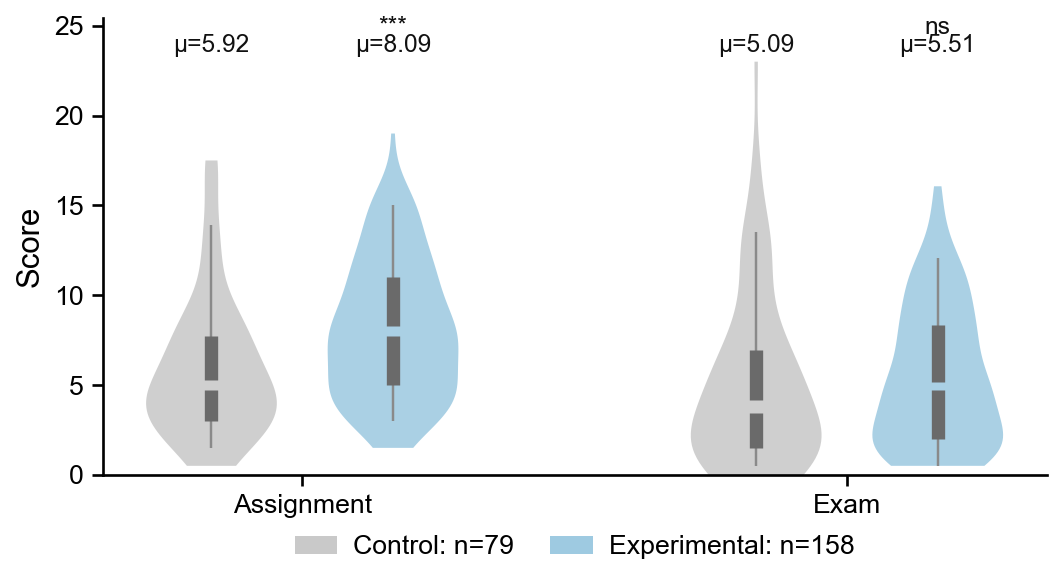

Saved figure: assignment_exam_control_vs_experimental_python.pdf


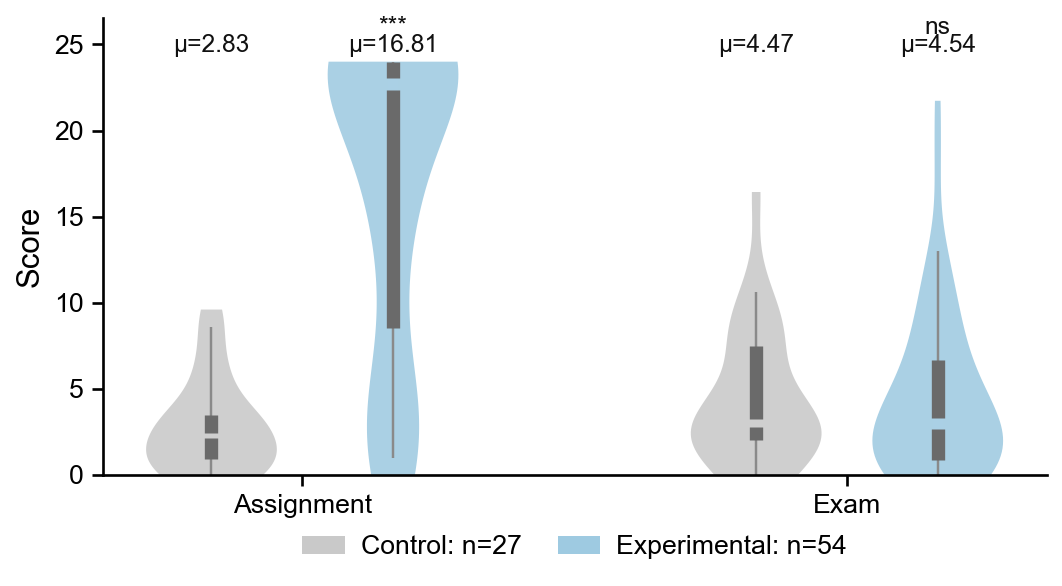

In [6]:
def _clean_values(values):
    cleaned = []
    for value in values:
        try:
            value = float(value)
        except (TypeError, ValueError):
            continue
        if np.isfinite(value):
            cleaned.append(value)
    return cleaned


def _significance_marker(p_value):
    if p_value is None or not np.isfinite(float(p_value)):
        return 'ns'
    p_value = float(p_value)
    if p_value < 0.001:
        return '***'
    if p_value < 0.01:
        return '**'
    if p_value < 0.05:
        return '*'
    return 'ns'


def _draw_violin_box(ax, values, position, color):
    values = np.asarray(_clean_values(values), dtype=float)
    if values.size == 0:
        return
    violin_alpha = 0.88
    parts = ax.violinplot(
        [values], positions=[position], widths=0.72,
        showmeans=False, showmedians=False, showextrema=False,
    )
    for body in parts['bodies']:
        body.set_facecolor(color)
        body.set_edgecolor(None)
        body.set_alpha(violin_alpha)

    q1, median, q3 = np.percentile(values, [25, 50, 75])
    low, high = np.percentile(values, [5, 95])
    span = float(np.max(values) - np.min(values) + 1e-9)
    gap = min(0.03 * span, 0.35 * max(1e-9, q3 - q1))
    gap_low = float(median - gap / 2)
    gap_high = float(median + gap / 2)

    ax.plot([position, position], [float(low), float(high)], color='#8A8A8A',
            linewidth=1.1, zorder=2, solid_capstyle='butt')
    try:
        from matplotlib.colors import to_rgba
        bg = ax.get_facecolor()
        base = to_rgba(color, 1.0)
        mask_color = tuple(
            violin_alpha * float(component) + (1.0 - violin_alpha) * float(background)
            for component, background in zip(base[:3], bg[:3])
        ) + (1.0,)
    except Exception:
        mask_color = color

    eps = 0.01 * span
    ax.plot([position, position], [gap_low - eps, gap_high + eps],
            color=mask_color, linewidth=4.7, zorder=2.6, solid_capstyle='butt')
    lower_end = max(q1, median - gap / 2)
    upper_start = min(q3, median + gap / 2)
    if lower_end > q1:
        ax.plot([position, position], [q1, lower_end], color='#6A6A6A',
                linewidth=6.0, solid_capstyle='butt', zorder=3)
    if q3 > upper_start:
        ax.plot([position, position], [upper_start, q3], color='#6A6A6A',
                linewidth=6.0, solid_capstyle='butt', zorder=3)


def _plot_course_violin_panel(ax, course, dataframe, comparison):
    from matplotlib.patches import Patch

    control_color = '#C9C9C9'
    experimental_color = '#9ecae1'
    specifications = [
        ('Assignment', 'hw1_score', 0, 1, control_color),
        ('Assignment', 'hw1_score', 1, 2, experimental_color),
        ('Exam', 'hw2_score', 0, 4, control_color),
        ('Exam', 'hw2_score', 1, 5, experimental_color),
    ]
    all_values = []
    means = {}
    for outcome_label, outcome, group, position, color in specifications:
        values = _clean_values(dataframe.loc[dataframe['group'] == group, outcome])
        all_values.extend(values)
        means[position] = float(np.mean(values)) if values else float('nan')
        _draw_violin_box(ax, values, position, color)

    y_min = float(min(all_values)) if all_values else 0.0
    y_max = float(max(all_values)) if all_values else 1.0
    span = max(1e-9, y_max - y_min)
    y_bottom = max(0.0, y_min - 0.06 * span)
    y_top = y_max + 0.105 * span
    ax.set_ylim(y_bottom, y_top)
    y_mu = y_max + 0.040 * span
    y_sig = y_max + 0.083 * span

    for outcome_label, outcome, group, position, _color in specifications:
        mean_value = means[position]
        if not np.isfinite(mean_value):
            continue
        ax.text(position, y_mu, f'μ={mean_value:.2f}', ha='center', va='center',
                fontsize=11, color='#111111', zorder=5)
        if group == 1:
            p_value = comparison.loc[
                (comparison['Course'] == course) & (comparison['Outcome'] == outcome_label),
                'p_value',
            ].iloc[0]
            ax.text(position, y_sig, _significance_marker(p_value), ha='center',
                    va='center', fontsize=11, color='#111111', zorder=5)

    control_n = int((dataframe['group'] == 0).sum())
    experimental_n = int((dataframe['group'] == 1).sum())
    handles = [
        Patch(facecolor=control_color, edgecolor='none', label=f'Control: n={control_n}'),
        Patch(facecolor=experimental_color, edgecolor='none', label=f'Experimental: n={experimental_n}'),
    ]
    ax.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, -0.08),
              ncol=2, frameon=False, fontsize=12, columnspacing=1.35,
              handlelength=1.6, handletextpad=0.6)
    ax.set_xticks([1.5, 4.5])
    ax.set_xticklabels(['Assignment', 'Exam'], fontsize=12)
    ax.set_xlim(0.4, 5.6)
    ax.set_ylabel('Score', fontsize=14)
    ax.tick_params(axis='y', labelsize=12)
    ax.grid(False)


def plot_course_score_comparison(course, dataframe, comparison, output_path):
    _set_nature_style_like_a1_behavior_analyze()
    fig, ax = plt.subplots(figsize=(6.8, 4.0), dpi=300)
    _plot_course_violin_panel(ax, course, dataframe, comparison)
    fig.tight_layout(rect=[0.0, 0.04, 1.0, 1.0])
    output_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(output_path, bbox_inches='tight')
    print('Saved figure:', relative_path(output_path))
    if SHOW_FIGURES:
        from IPython.display import Image, display
        preview = io.BytesIO()
        fig.savefig(preview, format='png', dpi=160, bbox_inches='tight')
        display(Image(data=preview.getvalue()))
    plt.close(fig)


score_comparison_paths = {
    'Game Theory': FIGURES_DIR / 'assignment_exam_control_vs_experimental_game_theory.pdf',
    'Python': FIGURES_DIR / 'assignment_exam_control_vs_experimental_python.pdf',
}
for course in COURSE_ORDER:
    plot_course_score_comparison(
        course, course_data_by_label[course], comparison_table, score_comparison_paths[course]
    )

## Output

The notebook writes `figures/assignment_exam_control_vs_experimental_game_theory.pdf` and `figures/assignment_exam_control_vs_experimental_python.pdf`. Each course is a separate full-width violin figure; no combined or pooled figure is generated.

In [7]:
print('Output files:')
for course in COURSE_ORDER:
    print(' ', relative_path(score_comparison_paths[course]))
print()
print('Course-specific Welch comparisons:')
for row in comparison_rows:
    print(f"  {row['Course']} {row['Outcome']}: {row['Score difference']:+.2f} score points, {_format_p(row['p_value'])}")

Output files:
  assignment_exam_control_vs_experimental_game_theory.pdf
  assignment_exam_control_vs_experimental_python.pdf

Course-specific Welch comparisons:
  Game Theory Assignment: +2.17 score points, p<0.001
  Game Theory Exam: +0.42 score points, p=0.501
  Python Assignment: +13.98 score points, p<0.001
  Python Exam: +0.07 score points, p=0.944
